In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Loading and viewing the data
data = pd.read_csv('BAJFINANCE.csv')
data.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,BAJAUTOFIN,EQ,46.95,49.45,50.75,46.5,50.75,50.75,50.05,7600,3.803800e+10,NaN,NaN,NaN
1,2000-01-04,BAJAUTOFIN,EQ,50.75,53.20,53.20,47.9,48.00,48.10,48.56,5000,2.428000e+10,NaN,NaN,NaN
2,2000-01-05,BAJAUTOFIN,EQ,48.10,46.55,47.40,44.6,44.60,44.60,45.47,3500,1.591450e+10,NaN,NaN,NaN
3,2000-01-06,BAJAUTOFIN,EQ,44.60,43.50,46.00,42.1,46.00,45.25,44.43,6200,2.754750e+10,NaN,NaN,NaN
4,2000-01-07,BAJAUTOFIN,EQ,45.25,48.00,48.00,42.0,42.90,42.90,44.44,3500,1.555550e+10,NaN,NaN,NaN


In [3]:
# Setting date as index
data.set_index('Date', inplace = True) #This code already ran so it's supposed to be here. If I do it again it'll throw an error because Date is already the index

In [4]:
data

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,
2000-01-03,BAJAUTOFIN,EQ,46.95,49.45,50.75,46.50,50.75,50.75,50.05,7600,3.803800e+10,NaN,NaN,NaN
2000-01-04,BAJAUTOFIN,EQ,50.75,53.20,53.20,47.90,48.00,48.10,48.56,5000,2.428000e+10,NaN,NaN,NaN
2000-01-05,BAJAUTOFIN,EQ,48.10,46.55,47.40,44.60,44.60,44.60,45.47,3500,1.591450e+10,NaN,NaN,NaN
2000-01-06,BAJAUTOFIN,EQ,44.60,43.50,46.00,42.10,46.00,45.25,44.43,6200,2.754750e+10,NaN,NaN,NaN
2000-01-07,BAJAUTOFIN,EQ,45.25,48.00,48.00,42.00,42.90,42.90,44.44,3500,1.555550e+10,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-26,BAJFINANCE,EQ,4667.80,4690.00,4829.00,4690.00,4744.00,4736.55,4768.93,2903989,1.384893e+15,175366.0,768523.0,0.2646
2021-04-27,BAJFINANCE,EQ,4736.55,4747.00,4889.85,4746.55,4886.00,4865.05,4818.15,2644997,1.274399e+15,148957.0,777955.0,0.2941
2021-04-28,BAJFINANCE,EQ,4865.05,4915.00,5310.00,4915.00,5255.00,5280.90,5158.33,8576454,4.424018e+15,466644.0,1420176.0,0.1656


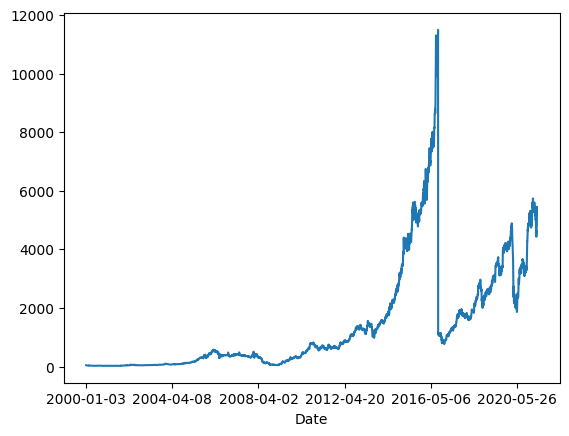

In [5]:
# Getting a plot of Volume Weighted Average Price, the target variable
data['VWAP'].plot()
plt.show()

In [6]:
data.shape

(5235, 14)

# Data Cleaning

In [7]:
# Checks for missing values
data.isna().sum()

Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2779
Deliverable Volume     446
%Deliverble            446
dtype: int64

In [99]:
# Drops all missing values
data.dropna(inplace = True) # Try imputing with mean or median

In [100]:
data.shape

(2450, 34)

In [101]:
df = data.copy()

In [102]:
# Checks data types (rolling features added below, original data did not have these)
df.dtypes

Symbol                     object
Series                     object
Prev Close                float64
Open                      float64
High                      float64
Low                       float64
Last                      float64
Close                     float64
VWAP                      float64
Volume                      int64
Turnover                  float64
Trades                    float64
Deliverable Volume        float64
%Deliverble               float64
Highrolling_mean_3        float64
Highrolling_mean_7        float64
Lowrolling_mean_3         float64
Lowrolling_mean_7         float64
Volumerolling_mean_3      float64
Volumerolling_mean_7      float64
Turnoverrolling_mean_3    float64
Turnoverrolling_mean_7    float64
Tradesrolling_mean_3      float64
Tradesrolling_mean_7      float64
Highrolling_std_3         float64
Highrolling_std_7         float64
Lowrolling_std_3          float64
Lowrolling_std_7          float64
Volumerolling_std_3       float64
Volumerolling_

# Feature Engineering

In [103]:
lag_features = ['High', 'Low', 'Volume', 'Turnover', 'Trades'] # lag features are values from a past time period used to model future time periods
window1 = 3
window2 = 7

In [104]:
# Adds 3 day and 7 day rolling mean for the 5 features
for feature in lag_features:
    data[feature + 'rolling_mean_3'] = data[feature].rolling(window = window1).mean()
    data[feature + 'rolling_mean_7'] = data[feature].rolling(window = window2).mean()

In [105]:
# Adds 3 day and 7 day rolling standard deviations for the 5 features
for feature in lag_features:
    data[feature + 'rolling_std_3'] = data[feature].rolling(window = window1).std()
    data[feature + 'rolling_std_7'] = data[feature].rolling(window = window2).std()

In [106]:
data.head()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,Highrolling_std_3,Highrolling_std_7,Lowrolling_std_3,Lowrolling_std_7,Volumerolling_std_3,Volumerolling_std_7,Turnoverrolling_std_3,Turnoverrolling_std_7,Tradesrolling_std_3,Tradesrolling_std_7
Date,,,,,,,,,,,,,,,,,,,,,
2011-06-09,BAJFINANCE,EQ,635.60,639.80,647.00,630.00,630.00,631.10,638.27,31252,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-06-10,BAJFINANCE,EQ,631.10,641.85,648.25,618.55,621.10,622.20,634.16,30885,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-06-13,BAJFINANCE,EQ,622.20,616.00,627.85,616.00,622.75,624.95,622.92,3981,...,11.434196,NaN,7.456597,NaN,15640.051929,NaN,9.982094e+11,NaN,557.373603,NaN
2011-06-14,BAJFINANCE,EQ,624.95,625.00,628.95,619.95,621.20,622.10,625.35,5597,...,11.473593,NaN,2.002707,NaN,15088.183102,NaN,9.595224e+11,NaN,656.385050,NaN
2011-06-15,BAJFINANCE,EQ,622.10,612.00,623.00,598.10,605.00,601.70,606.90,12590,...,3.165833,NaN,11.643560,NaN,4575.812970,NaN,2.733211e+11,NaN,150.639747,NaN


In [107]:
data.columns

Index(['Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble', 'Highrolling_mean_3', 'Highrolling_mean_7',
       'Lowrolling_mean_3', 'Lowrolling_mean_7', 'Volumerolling_mean_3',
       'Volumerolling_mean_7', 'Turnoverrolling_mean_3',
       'Turnoverrolling_mean_7', 'Tradesrolling_mean_3',
       'Tradesrolling_mean_7', 'Highrolling_std_3', 'Highrolling_std_7',
       'Lowrolling_std_3', 'Lowrolling_std_7', 'Volumerolling_std_3',
       'Volumerolling_std_7', 'Turnoverrolling_std_3', 'Turnoverrolling_std_7',
       'Tradesrolling_std_3', 'Tradesrolling_std_7'],
      dtype='object')

In [108]:
data.shape

(2450, 34)

In [109]:
# Drops all missing values (mainly from the rolling features)
data.dropna(inplace = True)

In [110]:
data.shape

(2444, 34)

In [111]:
independent_features = ['Highrolling_mean_3', 'Highrolling_mean_7',
       'Lowrolling_mean_3', 'Lowrolling_mean_7', 'Volumerolling_mean_3',
       'Volumerolling_mean_7', 'Turnoverrolling_mean_3',
       'Turnoverrolling_mean_7', 'Tradesrolling_mean_3',
       'Tradesrolling_mean_7', 'Highrolling_std_3', 'Highrolling_std_7',
       'Lowrolling_std_3', 'Lowrolling_std_7', 'Volumerolling_std_3',
       'Volumerolling_std_7', 'Turnoverrolling_std_3', 'Turnoverrolling_std_7',
       'Tradesrolling_std_3', 'Tradesrolling_std_7']

In [112]:
# Splitting the data into training and testing using an approximate 80/20 split
training_data = data[0:1960]
testing_data = data[1960:]

In [113]:
training_data

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,Highrolling_std_3,Highrolling_std_7,Lowrolling_std_3,Lowrolling_std_7,Volumerolling_std_3,Volumerolling_std_7,Turnoverrolling_std_3,Turnoverrolling_std_7,Tradesrolling_std_3,Tradesrolling_std_7
Date,,,,,,,,,,,,,,,,,,,,,
2011-06-17,BAJFINANCE,EQ,581.15,593.00,593.00,577.00,582.00,583.70,582.90,10410,...,28.023799,19.998696,13.630970,22.484643,1.336687e+04,1.324176e+04,7.859563e+11,8.221758e+11,235.606310,422.114800
2011-06-20,BAJFINANCE,EQ,583.70,570.00,582.05,553.80,570.00,571.90,566.55,15181,...,35.912405,25.619245,12.322337,26.265769,1.279868e+04,1.199032e+04,7.648574e+11,7.318860e+11,238.265258,406.056177
2011-06-21,BAJFINANCE,EQ,571.90,572.00,588.00,572.00,575.00,578.35,582.81,4289,...,5.481864,25.343389,12.209832,24.780650,5.459926e+03,1.069583e+04,3.065172e+11,6.266742e+11,148.021395,218.921164
2011-06-22,BAJFINANCE,EQ,578.35,576.00,585.75,562.25,566.00,566.10,574.92,6652,...,3.004302,26.244959,9.107735,22.547112,5.729504e+03,1.038975e+04,3.209172e+11,6.112641e+11,154.305973,220.517357
2011-06-23,BAJFINANCE,EQ,566.10,561.25,572.00,560.25,571.95,569.90,566.81,3206,...,8.661457,27.156519,6.286560,14.501679,1.762175e+03,1.069904e+04,1.020574e+11,6.325777e+11,46.306947,228.303787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-05-13,BAJFINANCE,EQ,2922.85,2929.90,2957.95,2906.00,2935.00,2931.85,2932.66,1356229,...,20.861707,71.798822,10.816654,84.266688,1.998260e+05,3.725632e+05,5.996578e+13,1.039593e+14,16229.861254,18600.605311
2019-05-14,BAJFINANCE,EQ,2931.85,2927.95,2941.95,2848.10,2885.75,2881.85,2889.20,1861760,...,27.764501,55.599706,31.838185,66.014663,2.530587e+05,3.692333e+05,7.030421e+13,1.022707e+14,13351.459134,14064.128138
2019-05-15,BAJFINANCE,EQ,2881.85,2921.00,3023.25,2870.80,3012.10,3002.75,2964.21,2453670,...,43.069285,42.665607,29.174018,50.565568,5.492868e+05,4.955057e+05,1.654045e+14,1.442652e+14,26880.039757,19876.366232


# Modelling

In [114]:
!pip install pmdarima

In [115]:
# Getting arima library as the model
from pmdarima import auto_arima

In [116]:
import warnings
warnings.filterwarnings('ignore')

In [129]:
# Fitting the auto arima model on the training data (using the rolling means and standard deviations as features)
model = auto_arima(y = training_data['VWAP'] , X = training_data[independent_features], trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=22678.205, Time=6.98 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=22672.925, Time=4.47 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=22674.683, Time=4.60 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=22674.678, Time=5.27 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=35570.812, Time=3.76 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=22676.940, Time=5.98 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0] intercept
Total fit time: 31.074 seconds


In [130]:
# Predicting on testing data using best model found in auto arima
forecast = model.predict(n_periods=len(testing_data), X = testing_data[independent_features])

In [120]:
testing_data['Forecast_ARIMA'] = forecast

In [137]:
# Table comparison of actual vs forecast values in testing period
testing_data[['VWAP' , 'Forecast_ARIMA']].head()

,VWAP,Forecast_ARIMA
Date,,
2019-05-20,3395.34,3312.283160
2019-05-21,3435.60,3430.494744
2019-05-22,3434.43,3410.858491
2019-05-23,3440.35,3376.506716
2019-05-24,3434.51,3346.649805


<Axes: xlabel='Date'>

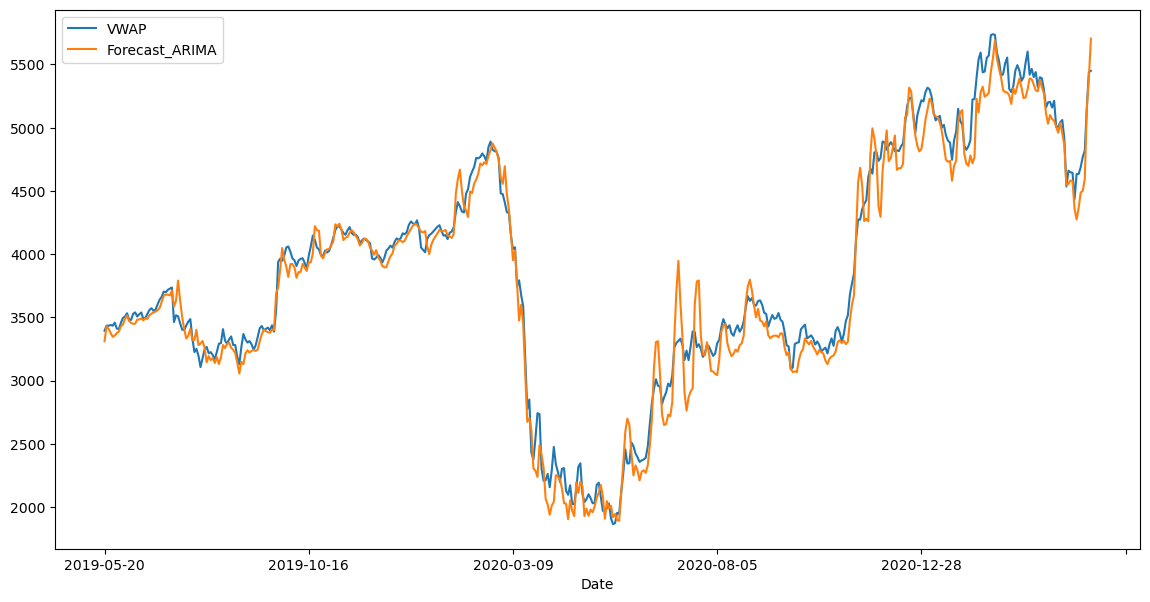

In [131]:
testing_data['Forecast_ARIMA'] = forecast.values
testing_data[['VWAP' , 'Forecast_ARIMA']].plot(figsize=(14,7))

In [139]:
# Loading RMSE and MAE from sklearn to evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error

print(np.sqrt(mean_squared_error(testing_data['VWAP'],testing_data['Forecast_ARIMA'])))
print(mean_absolute_error(testing_data['VWAP'],testing_data['Forecast_ARIMA']))

151.9076984516795
112.77050996283161


Based on MAE, average stock prediction is off by about $113, roughly 3-4% of the VWAP value. So not a bad model but not the best either